In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as pyplot

In [8]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [9]:
df.shape

(19158, 13)

In [10]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [74]:
#  we will apply CCA where missing data is less than 5%
# you have to make sure that the data is mising completely at random, then only you can apply CCA.
# but there still one problem, In production, if your model receives any missing value, if doesn't have any idea how to handle that.
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [17]:
df[cols].sample(5)   # columns in which some cells have missing values

,city_development_index,enrolled_university,education_level,experience,training_hours
15701,0.893,Full time course,Graduate,8.0,312.0
7234,0.910,Full time course,High School,3.0,50.0
9457,0.689,no_enrollment,Graduate,19.0,11.0
1014,0.920,no_enrollment,Graduate,10.0,78.0
7726,0.920,Full time course,High School,6.0,27.0


In [20]:
# if we drop all 'rows' in which missing value is there, then the percentage of data left
len(df[cols].dropna()) / len(df[cols])

0.8968577095730244

In [21]:
new_df = df[cols].dropna()

df.shape, new_df.shape

((19158, 13), (17182, 5))

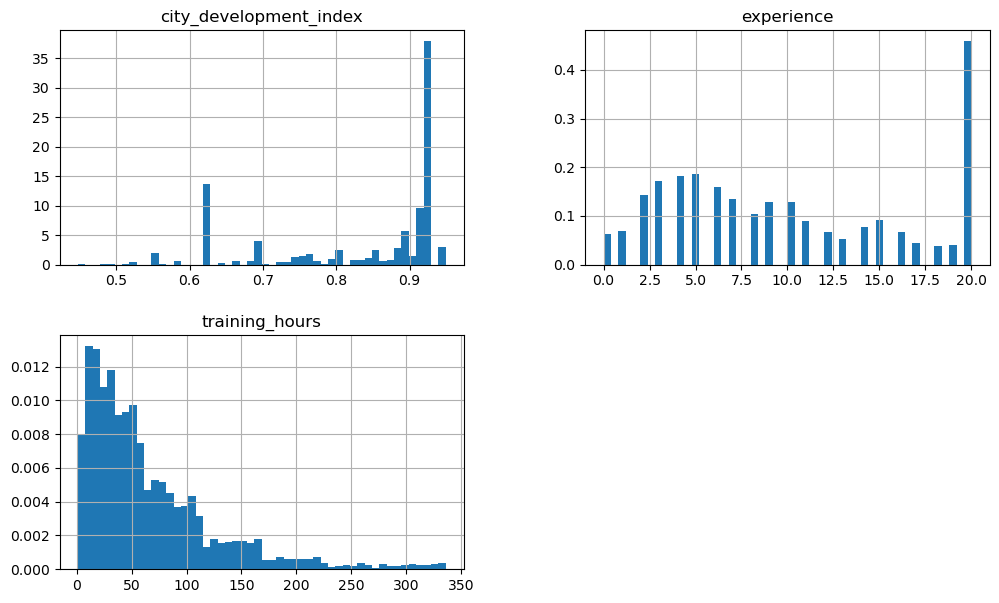

In [33]:
new_df.hist(bins=50, density=True, figsize=(12,7))
pyplot.show()

In [51]:
# if the data missing is at random, means it does not affect the distribution after removing that rows, 
# we can apply CCA.

<h3 style='color:brown'>Analysing Distribution of Numerical Columns</h3>

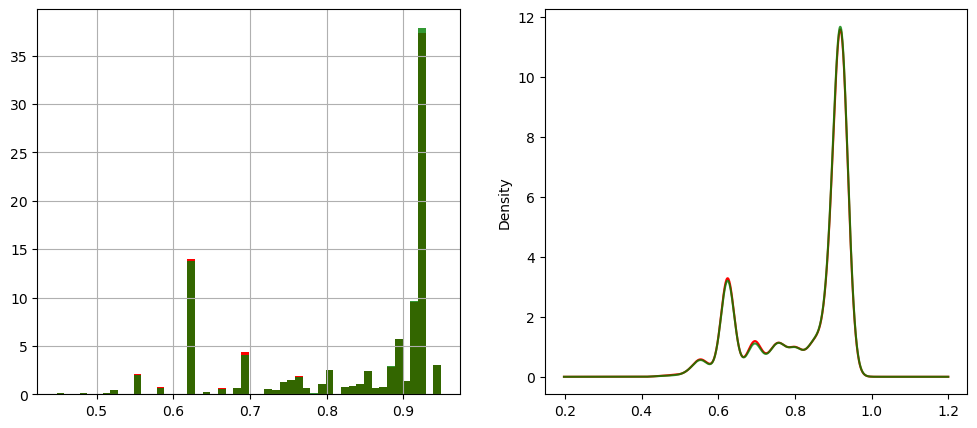

In [52]:
pyplot.figure(figsize=(12,5))

pyplot.subplot(121)    # histogram
df['city_development_index'].hist(bins=50, density=True, color='red')                    # original data
new_df['city_development_index'].hist(bins=50, color='green', density=True, alpha=0.8)   # data after cca, 
# the argument alpha makes the color transparent, so we can see the overlay of the 2 distributions

pyplot.subplot(122)   # pdf
df['city_development_index'].plot.density(color='red')                    # original data 
new_df['city_development_index'].plot.density(color='green', alpha=0.8)   # data after CCA

pyplot.show()

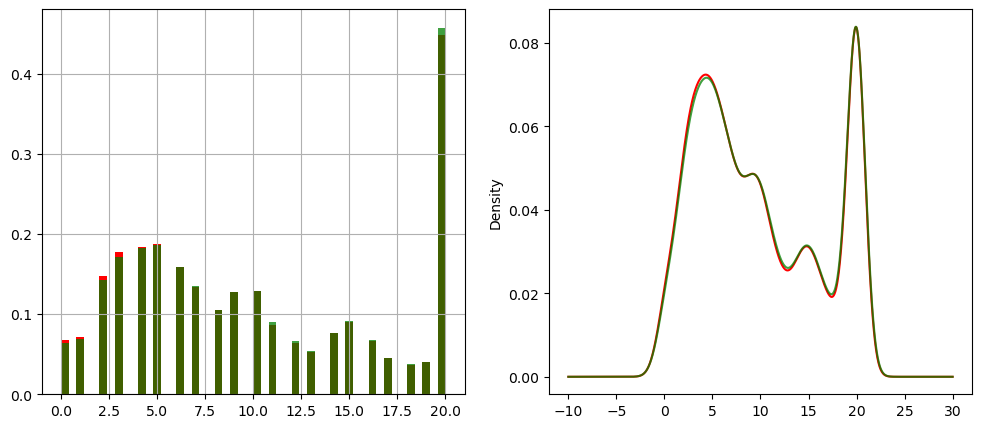

In [56]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)        # histogram
df['experience'].hist(bins=50, density=True, color='red')               #  original data 
new_df['experience'].hist(bins=50, density=True, alpha=0.75, color='green')   # data after CCA 

pyplot.subplot(122)       # pdf 
df['experience'].plot.density(color='red')                               #  original data 
new_df['experience'].plot.density(color='green', alpha=0.75)             # data after CCA 

pyplot.show()

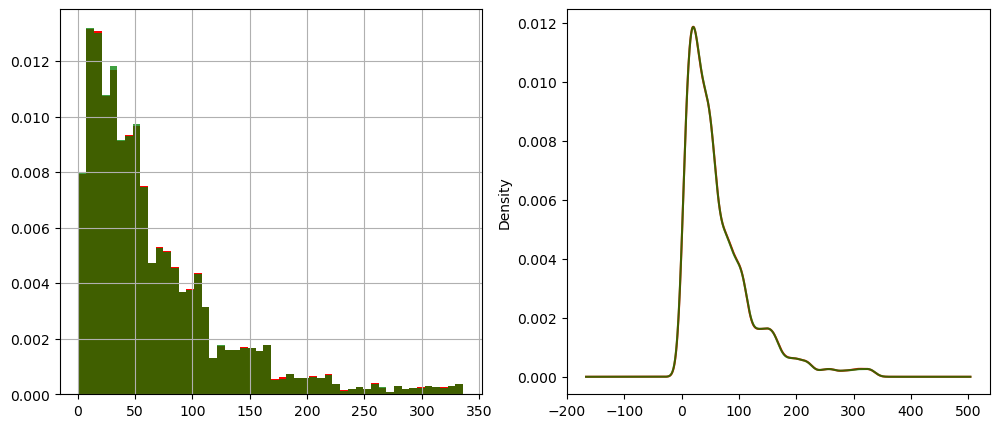

In [61]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)        # histogram
df['training_hours'].hist(bins=50, density=True, color='red')               #  original data 
new_df['training_hours'].hist(bins=50, density=True, alpha=0.75, color='green')   # data after CCA 

pyplot.subplot(122)       # pdf 
df['training_hours'].plot.density(color='red')                                  #  original data 
new_df['training_hours'].plot.density(color='green', alpha=0.75)             # data after CCA 

pyplot.show()

In [ ]:
# for cols in new_df.columns:
#     if df[cols].dtype == 'object':
#         continue
    
#     pyplot.figure(figsize=(12,5))
#     pyplot.subplot(121)
#     pyplot.hist(x=df[cols], bins=20, density=True, color='red', alpha=0.7)
#     pyplot.hist(x=new_df[cols], bins=20, density=True, color='green')
#     pyplot.title(f"Histogram for Column {cols}")
   
#     pyplot.subplot(122)
#     df[cols].plot.density(color='red', alpha=0.7)
#     new_df[cols].plot.density(color='green')
#     pyplot.title(f'Density Plot for Column {cols}')
#     pyplot.show()

<h3 style='color:brown'>Analysing Distribution of Categorical Columns</h3>

In [62]:
# for categorical columns we have to check the ratio of 
# different categories present in that column is same after applying CCA also.

In [63]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [72]:
# check if the ratio of 'no_enrollment' cstegory in the complete data is same as in the new_df or not.
# similarly check for other ratios too. 

ratio_check = pd.concat([
    # percentage of observations per category, original data
    df['enrolled_university'].value_counts() / len(df),
    
     # percentage of observations per category, cca data
     new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1)

ratio_check.columns = ['original', 'After CCA']             # add column names
ratio_check

,original,After CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [73]:
ratio_check = pd.concat([
    # percentage of observations per category, original data
    df['education_level'].value_counts() / len(df),
    
     # percentage of observations per category, cca data
     new_df['education_level'].value_counts() / len(new_df)
], axis=1)

ratio_check.columns = ['original', 'After CCA']             # add column names
ratio_check

,original,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
